In [1]:
import os
import glob
import random
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

IMAGES_DIR = Path("images")
LABELS_RAW_PATH = Path("labels_raw.json")

image_paths = sorted(glob.glob(str(IMAGES_DIR / "hard_hat_workers*.png")))
print(f"Всего изображений: {len(image_paths)}")


Всего изображений: 1001


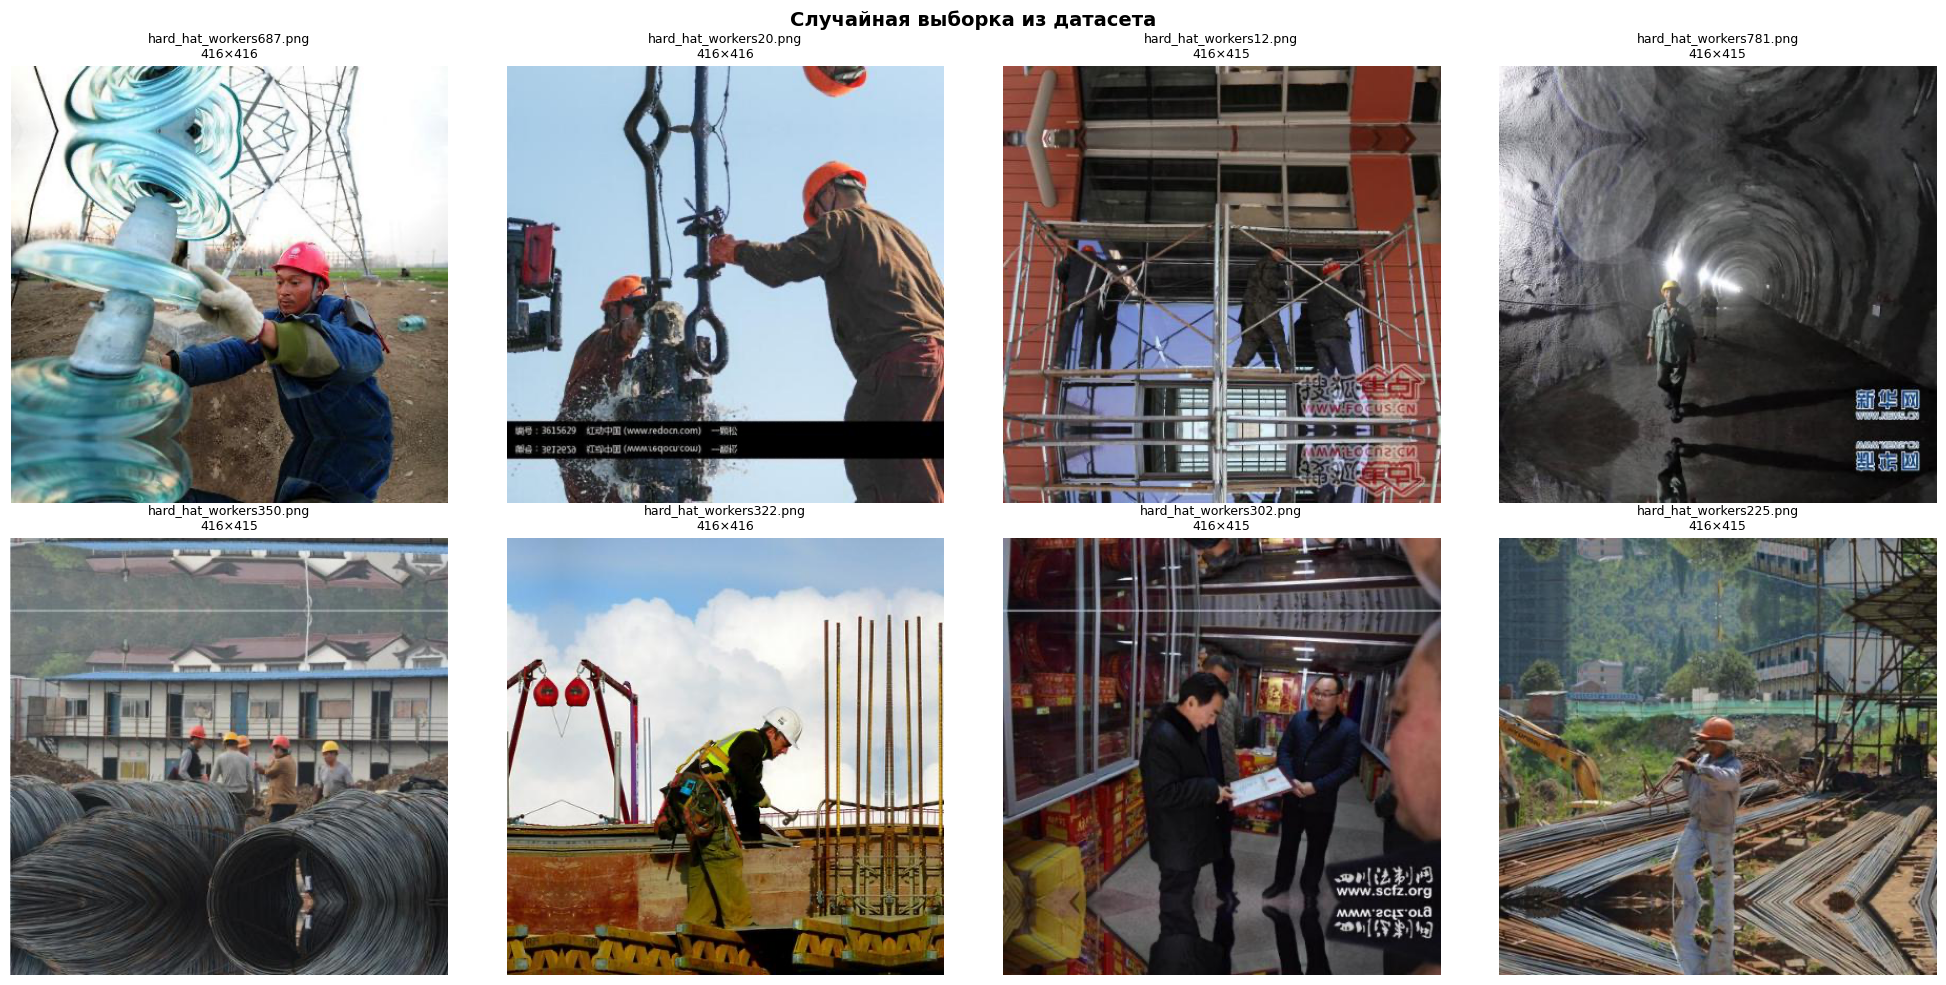

In [2]:
# Визуализация 8 случайных изображений
sample_paths = random.sample(image_paths, 8)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, img_path in zip(axes.flat, sample_paths):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"{Path(img_path).name}\n{img.size[0]}×{img.size[1]}", fontsize=9)
    ax.axis("off")
fig.suptitle("Случайная выборка из датасета", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


Ширина  — min: 415, max: 416, mean: 416
Высота  — min: 415, max: 416, mean: 416


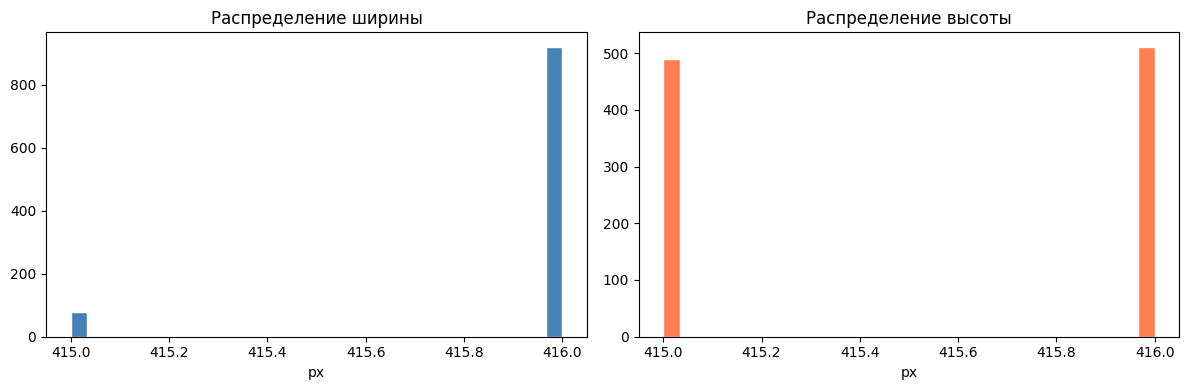

In [3]:
# Статистика по размерам изображений
widths, heights = [], []
for p in image_paths:
    with Image.open(p) as img:
        widths.append(img.width)
        heights.append(img.height)

print(f"Ширина  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Высота  — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Распределение ширины")
axes[0].set_xlabel("px")
axes[1].hist(heights, bins=30, color="coral", edgecolor="white")
axes[1].set_title("Распределение высоты")
axes[1].set_xlabel("px")
plt.tight_layout()
plt.show()


In [4]:
from vllm import LLM, SamplingParams
from transformers import AutoProcessor
from qwen_vl_utils import process_vision_info

MODEL_NAME = "Qwen/Qwen2.5-VL-3B-Instruct"

# Параметры для T4 (15 GB VRAM)
MAX_IMAGE_TOKENS = 1024
MAX_TEXT_TOKENS = 256
MAX_MODEL_LEN = MAX_IMAGE_TOKENS + MAX_TEXT_TOKENS + 512  # запас на system prompt + generation
MAX_PIXELS = MAX_IMAGE_TOKENS * 16 ** 2  # patch_size=16 для Qwen2.5-VL

processor = AutoProcessor.from_pretrained(MODEL_NAME)

llm = LLM(
    model=MODEL_NAME,
    max_model_len=MAX_MODEL_LEN,
    max_num_seqs=4,
    gpu_memory_utilization=0.85,
    tensor_parallel_size=1,
    hf_overrides={"rope_scaling": {"rope_type": "mrope"}},
    trust_remote_code=True,
)

sampling_params = SamplingParams(temperature=0.1, max_tokens=512)

print("vLLM модель загружена успешно!")


ModuleNotFoundError: No module named 'vllm'

In [ ]:
SYSTEM_PROMPT = """You are a precise object detection annotator. 
For each person visible in the image, determine if they are wearing a safety helmet or not.
Return a JSON array of objects. Each object must have:
- "label": "helmet" or "no_helmet"
- "bbox": [x_min, y_min, x_max, y_max] in pixel coordinates

Rules:
- Coordinates must be integers within image bounds.
- If no people are visible, return an empty array: []
- Do NOT include objects that are not people.
- Output ONLY valid JSON, no extra text."""


def build_messages(image_path: str) -> list[dict]:
    """Формирование сообщений для VQA-модели."""
    return [
        {
            "role": "system",
            "content": [{"type": "text", "text": SYSTEM_PROMPT}],
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": f"file://{image_path}",
                    "max_pixels": MAX_PIXELS,
                },
                {
                    "type": "text",
                    "text": "Detect all people and classify helmet/no_helmet. Return JSON array.",
                },
            ],
        },
    ]


def prepare_vllm_input(messages: list[dict], processor) -> dict:
    """Подготовка входов для vLLM."""
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs, video_kwargs = process_vision_info(
        messages,
        return_video_kwargs=True,
        return_video_metadata=True,
    )
    mm_data = {}
    if image_inputs is not None:
        mm_data["image"] = image_inputs
    if video_inputs is not None:
        mm_data["video"] = video_inputs
    return {
        "prompt": text,
        "multi_modal_data": mm_data,
        "mm_processor_kwargs": video_kwargs,
    }


print("Функции подготовки данных готовы.")


In [ ]:
import re
from tqdm import tqdm


def parse_json_response(text: str) -> list[dict]:
    """Извлечение JSON из ответа модели."""
    # Ищем JSON-массив в тексте
    text = text.strip()
    # Попробуем найти массив через regex
    match = re.search(r'\[.*\]', text, re.DOTALL)
    if match:
        try:
            data = json.loads(match.group())
            if isinstance(data, list):
                return data
        except json.JSONDecodeError:
            pass
    return []


# Генерация разметки батчами
BATCH_SIZE = 4
labels_raw = {}

print(f"Запускаем разметку {len(image_paths)} изображений батчами по {BATCH_SIZE}...")

for i in tqdm(range(0, len(image_paths), BATCH_SIZE), desc="Разметка"):
    batch_paths = image_paths[i : i + BATCH_SIZE]
    batch_inputs = []

    for img_path in batch_paths:
        messages = build_messages(img_path)
        vllm_input = prepare_vllm_input(messages, processor)
        batch_inputs.append(vllm_input)

    # Генерация
    outputs = llm.generate(
        [inp["prompt"] for inp in batch_inputs],
        sampling_params=sampling_params,
        use_tqdm=False,
    )

    for img_path, out in zip(batch_paths, outputs):
        response_text = out.outputs[0].text
        detections = parse_json_response(response_text)
        img_name = Path(img_path).stem
        labels_raw[img_name] = {
            "image_path": img_path,
            "raw_response": response_text,
            "detections": detections,
        }

# Сохранение
with open(LABELS_RAW_PATH, "w") as f:
    json.dump(labels_raw, f, indent=2, ensure_ascii=False)

print(f"\nРазметка завершена. Сохранено в {LABELS_RAW_PATH}")
print(f"Размечено изображений: {len(labels_raw)}")

# Статистика
n_with_det = sum(1 for v in labels_raw.values() if v["detections"])
n_empty = len(labels_raw) - n_with_det
print(f"С детекциями: {n_with_det}, пустых: {n_empty}")


In [ ]:
import shutil
from sklearn.model_selection import train_test_split

# Загрузка разметки
with open(LABELS_RAW_PATH, "r") as f:
    labels_raw = json.load(f)

CLASS_MAP = {"helmet": 0, "no_helmet": 1}

# Директории для YOLO датасета
DATASET_DIR = PROJECT_DIR / "dataset"
for split in ["train", "val"]:
    (DATASET_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / split / "labels").mkdir(parents=True, exist_ok=True)


def convert_to_yolo(detections: list[dict], img_w: int, img_h: int) -> list[str]:
    """Конвертация bbox [x_min, y_min, x_max, y_max] → YOLO [cx, cy, w, h] (нормализованные)."""
    yolo_lines = []
    for det in detections:
        label = det.get("label", "").lower().strip()
        bbox = det.get("bbox", [])

        if label not in CLASS_MAP or len(bbox) != 4:
            continue

        class_id = CLASS_MAP[label]
        x_min, y_min, x_max, y_max = bbox

        # Клампинг координат
        x_min = max(0, min(float(x_min), img_w))
        y_min = max(0, min(float(y_min), img_h))
        x_max = max(0, min(float(x_max), img_w))
        y_max = max(0, min(float(y_max), img_h))

        if x_max <= x_min or y_max <= y_min:
            continue

        # Нормализация
        cx = ((x_min + x_max) / 2) / img_w
        cy = ((y_min + y_max) / 2) / img_h
        w = (x_max - x_min) / img_w
        h = (y_max - y_min) / img_h

        # Фильтр слишком маленьких/больших bbox
        if w < 0.005 or h < 0.005 or w > 0.95 or h > 0.95:
            continue

        yolo_lines.append(f"{class_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")

    return yolo_lines


# Конвертация всех изображений
valid_items = []  # (img_name, img_path, yolo_lines)
skipped = 0

for img_name, data in labels_raw.items():
    img_path = data["image_path"]
    detections = data["detections"]

    if not detections:
        skipped += 1
        continue

    with Image.open(img_path) as img:
        img_w, img_h = img.size

    yolo_lines = convert_to_yolo(detections, img_w, img_h)
    if yolo_lines:
        valid_items.append((img_name, img_path, yolo_lines))
    else:
        skipped += 1

print(f"Валидных изображений с bbox: {len(valid_items)}")
print(f"Пропущено (нет детекций / невалидные bbox): {skipped}")


In [ ]:
# Train/Val split 80/20
train_items, val_items = train_test_split(
    valid_items, test_size=0.2, random_state=SEED
)
print(f"Train: {len(train_items)}, Val: {len(val_items)}")


def save_split(items, split: str):
    """Копирование изображений и сохранение YOLO-лейблов."""
    for img_name, img_path, yolo_lines in items:
        # Копируем изображение
        dst_img = DATASET_DIR / split / "images" / f"{img_name}.png"
        shutil.copy2(img_path, dst_img)

        # Сохраняем лейбл
        dst_label = DATASET_DIR / split / "labels" / f"{img_name}.txt"
        with open(dst_label, "w") as f:
            f.write("\n".join(yolo_lines))


save_split(train_items, "train")
save_split(val_items, "val")
print("Датасет сохранён в", DATASET_DIR)


In [ ]:
# Создание data.yaml для YOLO
data_yaml_path = DATASET_DIR / "data.yaml"
data_yaml_content = f"""path: {DATASET_DIR}
train: train/images
val: val/images

names:
  0: helmet
  1: no_helmet
"""

with open(data_yaml_path, "w") as f:
    f.write(data_yaml_content)

print(f"data.yaml сохранён: {data_yaml_path}")

# Статистика по классам
from collections import Counter

class_counter = Counter()
for _, _, yolo_lines in valid_items:
    for line in yolo_lines:
        cls_id = int(line.split()[0])
        class_counter[cls_id] += 1

print(f"\nРаспределение классов:")
for cls_id, count in sorted(class_counter.items()):
    name = {0: "helmet", 1: "no_helmet"}[cls_id]
    print(f"  {name}: {count}")


In [ ]:
# Визуализация bbox на случайных изображениях
def visualize_annotations(items: list, n: int = 8, title: str = ""):
    """Отрисовка bbox на изображениях."""
    sample = random.sample(items, min(n, len(items)))
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))

    colors = {0: "lime", 1: "red"}
    label_names = {0: "helmet", 1: "no_helmet"}

    for ax, (img_name, img_path, yolo_lines) in zip(axes.flat, sample):
        img = Image.open(img_path)
        img_w, img_h = img.size
        ax.imshow(img)

        for line in yolo_lines:
            parts = line.split()
            cls_id = int(parts[0])
            cx, cy, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])

            # Денормализация
            x_min = (cx - w / 2) * img_w
            y_min = (cy - h / 2) * img_h
            box_w = w * img_w
            box_h = h * img_h

            rect = patches.Rectangle(
                (x_min, y_min), box_w, box_h,
                linewidth=2, edgecolor=colors[cls_id], facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(
                x_min, y_min - 5, label_names[cls_id],
                color=colors[cls_id], fontsize=8, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.7),
            )

        ax.set_title(f"{img_name}", fontsize=9)
        ax.axis("off")

    fig.suptitle(title or "Визуализация разметки", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


visualize_annotations(valid_items, n=8, title="Оценка качества авторазметки (случайные примеры)")


In [ ]:
# Статистика по bbox
bbox_areas = []
bbox_counts_per_image = []

for _, img_path, yolo_lines in valid_items:
    bbox_counts_per_image.append(len(yolo_lines))
    with Image.open(img_path) as img:
        img_w, img_h = img.size
    for line in yolo_lines:
        parts = line.split()
        w, h = float(parts[3]), float(parts[4])
        area = w * h * img_w * img_h
        bbox_areas.append(area)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(bbox_counts_per_image, bins=range(0, max(bbox_counts_per_image) + 2),
             color="steelblue", edgecolor="white")
axes[0].set_title("Число bbox на изображение")
axes[0].set_xlabel("Кол-во bbox")
axes[0].set_ylabel("Кол-во изображений")

axes[1].hist(bbox_areas, bins=50, color="coral", edgecolor="white")
axes[1].set_title("Площадь bbox (px²)")
axes[1].set_xlabel("Площадь")
axes[1].set_ylabel("Кол-во")
plt.tight_layout()
plt.show()

print(f"Среднее число bbox на изображение: {np.mean(bbox_counts_per_image):.1f}")
print(f"Средняя площадь bbox: {np.mean(bbox_areas):.0f} px²")


In [ ]:
from ultralytics import YOLO

# Освобождаем GPU от vLLM
import torch
import gc

# Удаляем vLLM объекты если они ещё в памяти
if "llm" in dir():
    del llm
if "processor" in dir():
    del processor
gc.collect()
torch.cuda.empty_cache()
print(f"GPU память освобождена. Доступно: {torch.cuda.mem_get_info()[0] / 1024**3:.1f} GB")


In [ ]:
# Загрузка и обучение YOLOv8n
model = YOLO("yolov8n.pt")

results = model.train(
    data=str(DATASET_DIR / "data.yaml"),
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    device=0,
    project=str(PROJECT_DIR / "runs"),
    name="helmet_detection",
    exist_ok=True,
    verbose=True,
)

print("Обучение завершено!")


In [ ]:
# Визуализация результатов обучения
results_dir = PROJECT_DIR / "runs" / "helmet_detection"

# Отображаем графики обучения
for plot_name in ["results.png", "confusion_matrix.png", "confusion_matrix_normalized.png"]:
    plot_path = results_dir / plot_name
    if plot_path.exists():
        img = Image.open(plot_path)
        fig, ax = plt.subplots(figsize=(14, 10))
        ax.imshow(img)
        ax.set_title(plot_name, fontsize=14, fontweight="bold")
        ax.axis("off")
        plt.tight_layout()
        plt.show()


In [ ]:
# Валидация модели
best_model_path = results_dir / "weights" / "best.pt"
model_best = YOLO(str(best_model_path))
val_metrics = model_best.val(data=str(DATASET_DIR / "data.yaml"), device=0)

print(f"\n=== Метрики на валидации ===")
print(f"mAP50:    {val_metrics.box.map50:.4f}")
print(f"mAP50-95: {val_metrics.box.map:.4f}")
print(f"Precision: {val_metrics.box.mp:.4f}")
print(f"Recall:    {val_metrics.box.mr:.4f}")


In [ ]:
# Инференс на валидационных изображениях
val_images_dir = DATASET_DIR / "val" / "images"
val_image_paths = sorted(glob.glob(str(val_images_dir / "*.png")))

# Предикты на нескольких примерах
sample_val = random.sample(val_image_paths, min(8, len(val_image_paths)))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, img_path in zip(axes.flat, sample_val):
    # Предикт
    pred_results = model_best.predict(img_path, conf=0.25, device=0, verbose=False)
    pred = pred_results[0]

    # Отрисовка
    img = Image.open(img_path)
    ax.imshow(img)
    img_w, img_h = img.size

    colors_pred = {0: "cyan", 1: "magenta"}
    label_names_pred = {0: "helmet", 1: "no_helmet"}

    if pred.boxes is not None:
        for box in pred.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            color = colors_pred.get(cls_id, "yellow")
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(
                x1, y1 - 5,
                f"{label_names_pred.get(cls_id, '?')} {conf:.2f}",
                color=color, fontsize=8, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.7),
            )

    ax.set_title(Path(img_path).name, fontsize=9)
    ax.axis("off")

fig.suptitle("Предсказания модели на валидации", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
# Анализ: сравнение предсказаний с GT-разметкой
# Примеры FP и FN
def analyze_errors(model, val_items, n_examples: int = 4):
    """Анализ ошибок: FP и FN примеры."""
    fp_examples = []  # False Positive: модель нашла, а в GT нет
    fn_examples = []  # False Negative: в GT есть, а модель не нашла

    for img_name, img_path, gt_lines in val_items:
        pred_results = model.predict(img_path, conf=0.25, device=0, verbose=False)
        pred = pred_results[0]
        n_pred = len(pred.boxes) if pred.boxes is not None else 0
        n_gt = len(gt_lines)

        if n_pred > n_gt and len(fp_examples) < n_examples:
            fp_examples.append((img_name, img_path, gt_lines, n_pred, n_gt))
        elif n_pred < n_gt and len(fn_examples) < n_examples:
            fn_examples.append((img_name, img_path, gt_lines, n_pred, n_gt))

        if len(fp_examples) >= n_examples and len(fn_examples) >= n_examples:
            break

    return fp_examples, fn_examples


fp_examples, fn_examples = analyze_errors(model_best, val_items)

print(f"Примеры FP (ложные срабатывания): {len(fp_examples)}")
for name, _, _, n_pred, n_gt in fp_examples:
    print(f"  {name}: pred={n_pred}, gt={n_gt}")

print(f"\nПримеры FN (пропуски): {len(fn_examples)}")
for name, _, _, n_pred, n_gt in fn_examples:
    print(f"  {name}: pred={n_pred}, gt={n_gt}")
